# House Price — Experiment v1

**Objective:** Build a regression model to predict house sale prices.

**Dataset:** Ames Housing

**Experiment:** v1


In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pickle
import wandb
import torch

In [13]:
# ============================================================
# TOÀN BỘ THAM SỐ CỦA NOTEBOOK
# Chỉ cần chỉnh sửa từ điển params này để thay đổi kịch bản
# ============================================================

params = {

    # --------------------------------------------------------
    # 1. Dữ liệu
    # --------------------------------------------------------
    "data": {
        "input_dir": "../../data",
        "train_file": "train.csv",
        "test_file": "test.csv",
        "target": "SalePrice",
        "validation_size": 0.20,
        "random_state": 42
    },

    # --------------------------------------------------------
    # 2. Thí nghiệm và nơi lưu kết quả
    # --------------------------------------------------------
    "experiment": {
        "expr_dir": "../",
        "expr_name": "house_price_v1",

        "best_model_file": "best_model.pt",
        "params_file": "params.json",

        "save_figures": True,
        "images_dir": "images",
        "figure_dpi": 150,

        "submission_file": "submission.csv",
        "submission_dir": "../../submissions",

        "tuning_results_file": "tuning_results.csv"
    },

    # --------------------------------------------------------
    # 3. W&B
    # --------------------------------------------------------
    "wandb": {
        "mode": "disabled",
        "project": "house-price-pytorch"
    },

    # --------------------------------------------------------
    # 4. Huấn luyện mặc định
    # --------------------------------------------------------
    "train": {
        "hidden1": 128,
        "hidden2": 64,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 100
    },

    # --------------------------------------------------------
    # 5. Các cấu hình tuning
    # --------------------------------------------------------
    "tuning": [
        {
            "name": "small",
            "hidden1": 64,
            "hidden2": 32,
            "learning_rate": 0.001,
            "batch_size": 32,
            "epochs": 100
        },
        {
            "name": "medium",
            "hidden1": 128,
            "hidden2": 64,
            "learning_rate": 0.001,
            "batch_size": 32,
            "epochs": 100
        },
        {
            "name": "large",
            "hidden1": 256,
            "hidden2": 128,
            "learning_rate": 0.001,
            "batch_size": 32,
            "epochs": 100
        }
    ],

    # --------------------------------------------------------
    # 6. Evaluation
    # --------------------------------------------------------
    "evaluation": {
        "metric": "RMSE"
    }
}

In [11]:
import os
from datetime import datetime
import json
# ============================================================
# KHỞI TẠO THƯ MỤC VÀ CÁC ARTIFACT CỦA THÍ NGHIỆM
# ============================================================

expr_path = os.path.join(
    params["experiment"]["expr_dir"],
    params["experiment"]["expr_name"]
)

os.makedirs(expr_path, exist_ok=True)


# ------------------------------------------------------------
# Các file nằm trực tiếp trong thư mục thí nghiệm
# ------------------------------------------------------------

best_model_path = os.path.join(
    expr_path,
    params["experiment"]["best_model_file"]
)

params_path = os.path.join(
    expr_path,
    params["experiment"]["params_file"]
)

tuning_results_path = os.path.join(
    expr_path,
    params["experiment"]["tuning_results_file"]
)


# ------------------------------------------------------------
# Thư mục chứa ảnh
# ------------------------------------------------------------

images_path = os.path.join(
    expr_path,
    params["experiment"]["images_dir"]
)

os.makedirs(images_path, exist_ok=True)


# ------------------------------------------------------------
# Submission
# ------------------------------------------------------------

submission_dir = params["experiment"]["submission_dir"]

os.makedirs(submission_dir, exist_ok=True)

submission_path = os.path.join(
    submission_dir,
    params["experiment"]["submission_file"]
)


# ------------------------------------------------------------
# Dump params xuống JSON
# ------------------------------------------------------------

with open(params_path, "w", encoding="utf-8") as f:
    json.dump(
        params,
        f,
        ensure_ascii=False,
        indent=4
    )


# ------------------------------------------------------------
# Tự động lưu matplotlib figure khi plt.show()
# ------------------------------------------------------------

_original_plt_show = plt.show
_figure_counter = 0


def show_and_save(*args, **kwargs):
    global _figure_counter

    if params["experiment"]["save_figures"] and plt.get_fignums():
        _figure_counter += 1

        figure_name = f"figure_{_figure_counter:03d}.png"
        figure_path = os.path.join(
            images_path,
            figure_name
        )

        fig = plt.gcf()

        fig.savefig(
            figure_path,
            dpi=params["experiment"]["figure_dpi"],
            bbox_inches="tight"
        )

        print(f"[FIGURE] Đã lưu: {figure_path}")

    return _original_plt_show(*args, **kwargs)


plt.show = show_and_save


# ------------------------------------------------------------
# Thông tin khởi tạo
# ------------------------------------------------------------

print("=" * 70)
print("BẮT ĐẦU THÍ NGHIỆM")
print("Thời gian         :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("PyTorch           :", torch.__version__)
print("Experiment        :", params["experiment"]["expr_name"])
print("expr_path         :", expr_path)
print("params_path       :", params_path)
print("best_model_path   :", best_model_path)
print("images_path       :", images_path)
print("tuning_results    :", tuning_results_path)
print("submission_path   :", submission_path)
print("=" * 70)

print("\nTHAM SỐ HUẤN LUYỆN:")
print(params["train"])

print("\nCÁC CẤU HÌNH TUNING:")
for cfg in params["tuning"]:
    print(cfg)

BẮT ĐẦU THÍ NGHIỆM
Thời gian         : 2026-09-21 14:28:41
PyTorch           : 2.14.0+cpu
Experiment        : house_price_v1
expr_path         : ../house_price_v1
params_path       : ../house_price_v1\params.json
best_model_path   : ../house_price_v1\best_model.pt
images_path       : ../house_price_v1\images
tuning_results    : ../house_price_v1\tuning_results.csv
submission_path   : ../../submissions\submission.csv

THAM SỐ HUẤN LUYỆN:
{'hidden1': 128, 'hidden2': 64, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}

CÁC CẤU HÌNH TUNING:
{'name': 'small', 'hidden1': 64, 'hidden2': 32, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}
{'name': 'medium', 'hidden1': 128, 'hidden2': 64, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}
{'name': 'large', 'hidden1': 256, 'hidden2': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}


## Load data

In [14]:
train_df = pd.read_csv(
    os.path.join(
        params["data"]["input_dir"],
        params["data"]["train_file"]
    )
)

test_df = pd.read_csv(
    os.path.join(
        params["data"]["input_dir"],
        params["data"]["test_file"]
    )
)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (1460, 81)
Test shape : (1459, 80)


In [15]:
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Check for NULL values

In [16]:
print(train_df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


<Axes: >

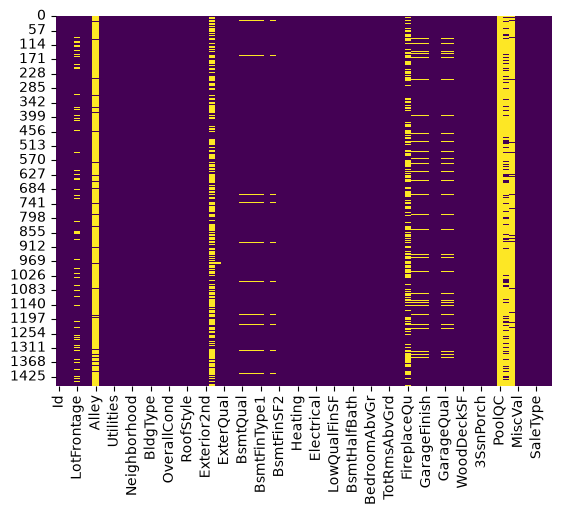

In [17]:
sns.heatmap(train_df.isnull(), cbar=False, cmap="viridis")

## Test data

In [18]:
print(test_df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

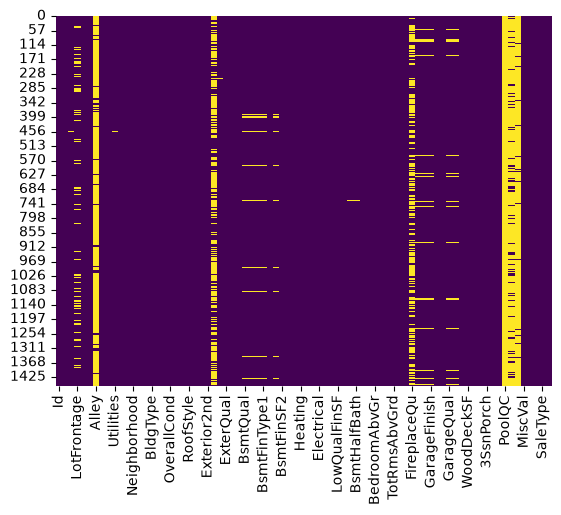

In [19]:
sns.heatmap(test_df.isnull(), cbar=False, cmap="viridis")

## Handling NULL data

### For train data

In [20]:
cat_col_train = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
'BsmtCond', 'BsmtExposure','BsmtFinType1', 'BsmtFinType2',
'GarageQual','GarageCond']

ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_train:
    train_df[i] = train_df[i].fillna(train_df[i].mode()[0])

for j in ncat_col_train:
    train_df[j] = train_df[j].fillna(train_df[j].mean())

### For test data

In [21]:
cat_col_test = [
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageQual',
    'GarageCond',
    'MSZoning',
    'Utilities',
    'Exterior1st',
    'Exterior2nd',
    'KitchenQual',
    'Functional',
    'SaleType'
]

ncat_col_test = [
    'LotFrontage',
    'GarageYrBlt',
    'MasVnrArea',
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'TotalBsmtSF',
    'BsmtFullBath',
    'BsmtHalfBath',
    'GarageCars',
    'GarageArea'
]

for i in cat_col_test:
    test_df[i] = test_df[i].fillna(test_df[i].mode()[0])

for j in ncat_col_test:
    test_df[j] = test_df[j].fillna(test_df[j].mean())

## Drop columns

<Axes: >

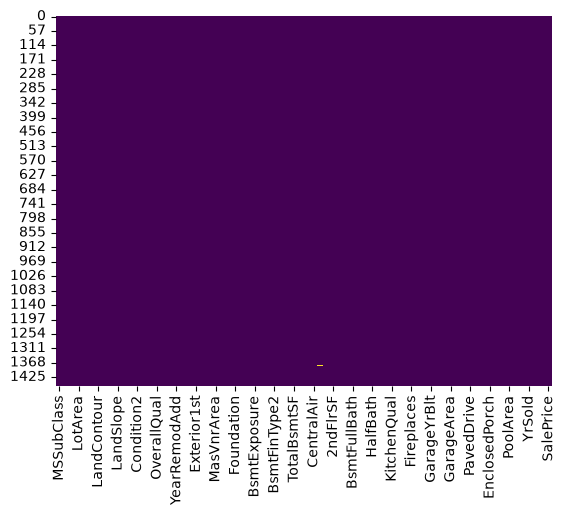

In [23]:
to_drop =  ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

for k in to_drop:
    train_df.drop(k, axis=1, inplace=True)
    test_df.drop(k, axis=1, inplace=True)

sns.heatmap(train_df.isnull(), cbar=False, cmap="viridis")

<Axes: >

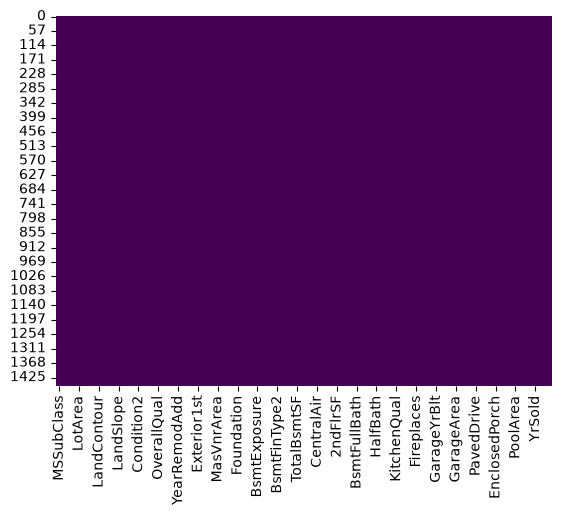

In [24]:
sns.heatmap(test_df.isnull(), cbar=False, cmap="viridis")

In [26]:
print("train_df shape:", train_df.shape)
print("test_df shape :", test_df.shape)

train_df shape: (1460, 76)
test_df shape : (1459, 75)


In [27]:
final_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
final_df.shape

(2919, 76)

In [ ]:
all_cat_col = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 
'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 
'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2','Heating', 'HeatingQC', 
'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 
'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0

    for fields in multicol:

        print(fields)
        df1 = pd.get_dummies(final_df[fields],drop_first = True)

        final_df.drop([fields], axis = 1, inplace = True)
        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final,df1], axis=1)
        i = i+1

    df_final = pd.concat([final_df,df_final], axis = 1)

    return df_final

final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


In [29]:
final_df.shape

(2919, 236)

In [30]:
final_df = final_df.loc[:,~final_df.columns.duplicated()]
final_df.shape

(2919, 176)

In [31]:
df_train = final_df.iloc[:1460, :]
df_test = final_df.iloc[1460:, :]

df_test.drop(['SalePrice'], axis=1, inplace=True)

print("train_df shape:", df_train.shape)
print("test_df shape :", df_test.shape)

train_df shape: (1460, 176)
test_df shape : (1459, 175)


## Training Data

In [32]:
x_train = df_train.drop(['SalePrice'], axis=1)
y_train = df_train['SalePrice']

## XGBoost

In [34]:
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


print("\nKiểu dữ liệu:")
print(x_train.dtypes.value_counts())

print("\nSố missing:")
print(x_train.isna().sum().sum())

X_train shape: (1460, 175)
y_train shape: (1460,)

Kiểu dữ liệu:
bool       139
int64       25
float64     11
Name: count, dtype: int64

Số missing:
0


In [35]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor()

xgb_model.fit(
    x_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [36]:
print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [37]:
for name, value in xgb_model.get_params().items():
    print(f"{name}: {value}")

objective: reg:squarederror
base_score: None
booster: None
callbacks: None
colsample_bylevel: None
colsample_bynode: None
colsample_bytree: None
device: None
early_stopping_rounds: None
enable_categorical: True
eval_metric: None
feature_types: None
feature_weights: None
gamma: None
grow_policy: None
importance_type: None
interaction_constraints: None
learning_rate: None
max_bin: None
max_cat_threshold: None
max_cat_to_onehot: None
max_delta_step: None
max_depth: None
max_leaves: None
min_child_weight: None
missing: nan
monotone_constraints: None
multi_strategy: None
n_estimators: None
n_jobs: None
num_parallel_tree: None
random_state: None
reg_alpha: None
reg_lambda: None
sampling_method: None
scale_pos_weight: None
subsample: None
tree_method: None
validate_parameters: None
verbosity: None


In [38]:
param = {
    'n_estimators': [100, 500, 900, 1100, 1500],
    'max_depth': [2, 3, 5, 10, 15],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1, 2, 3, 4],
    'booster': ['gbtree', 'gblinear'],
    'base_score': [0.25, 0.5, 0.75, 1]
}

In [39]:
from sklearn.model_selection import RandomizedSearchCV

random_cv = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param,
    cv=5,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    n_jobs=4,
    verbose=5,
    return_train_score=True,
    random_state=42
)

random_cv.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'base_score': [0.25, 0.5, ...], 'booster': ['gbtree', 'gblinear'], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the p

In [40]:
print("Best parameters:")
print(random_cv.best_params_)

print("\nBest score:")
print(random_cv.best_score_)

Best parameters:
{'n_estimators': 1100, 'min_child_weight': 4, 'max_depth': 3, 'learning_rate': 0.1, 'booster': 'gbtree', 'base_score': 1}

Best score:
-15607.194247645548


In [41]:
best_model = random_cv.best_estimator_
print(best_model)

XGBRegressor(base_score=1, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=4, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1100,
             n_jobs=None, num_parallel_tree=None, ...)


In [42]:
print("Id in X_train:", "Id" in x_train.columns)
print("Id in df_test:", "Id" in df_test.columns)

Id in X_train: False
Id in df_test: False


In [43]:
best_model = random_cv.best_estimator_

y_pred = best_model.predict(df_test)

print("Prediction shape:", y_pred.shape)
print("First 5 predictions:", y_pred[:5])

Prediction shape: (1459,)
First 5 predictions: [125976.08 159031.45 190508.69 196171.67 177811.48]


In [44]:
import pickle
import os

best_model = random_cv.best_estimator_

model_path = os.path.join(
    expr_path,
    "xgb_best_model.pkl"
)

with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print("Saved:", model_path)

Saved: ../house_price_v1\xgb_best_model.pkl


In [45]:
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

y_pred = loaded_model.predict(df_test)

print("Prediction shape:", y_pred.shape)
print("First 5 predictions:", y_pred[:5])

Prediction shape: (1459,)
First 5 predictions: [125976.08 159031.45 190508.69 196171.67 177811.48]


In [46]:
test_original = pd.read_csv(
    os.path.join(
        params["data"]["input_dir"],
        params["data"]["test_file"]
    )
)

submission = pd.DataFrame({
    "Id": test_original["Id"],
    "SalePrice": y_pred
})

print(submission.head())
print("Shape:", submission.shape)

     Id      SalePrice
0  1461  125976.078125
1  1462  159031.453125
2  1463  190508.687500
3  1464  196171.671875
4  1465  177811.484375
Shape: (1459, 2)


In [47]:
submission_path = os.path.join(
    params["experiment"]["submission_dir"],
    params["experiment"]["submission_file"]
)

submission.to_csv(submission_path, index=False)

print("Saved:", submission_path)

Saved: ../../submissions\submission.csv


In [48]:
tuning_results = pd.DataFrame(random_cv.cv_results_)

tuning_results.to_csv(
    os.path.join(expr_path, "tuning_results.csv"),
    index=False
)

print("Saved tuning results!")

Saved tuning results!
